This is a tutorial with examples of peak-fitting to various lineshapes, including multiple peaks, with baseline parameters, making use of parameter bounds.

The peak-fitting functions are primarily contained in pyFidA.fidA_processing.op_peak_fitting.py and makes use of the curvefit_tools.py module in the same folder.

In [1]:
import sys
sys.path.append('../..')
import pyFidA
import numpy as np
import matplotlib.pyplot as plt

## Sample data
First, create some data that we can use as an example. We will create three Lorentzian peaks of varying height and width, and add noise to them.

Text(0.5, 1.0, 'Sample data')

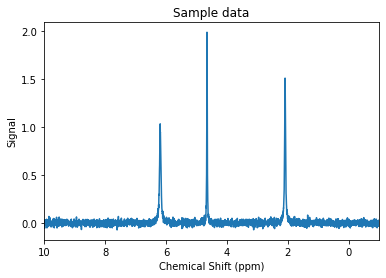

In [4]:
ppmvec=np.linspace(11,-2,4096)
# Parameter order is [amplitudes, FWHM_in_ppm, frequencies_in_ppm]
multi_parvec=[[1.5,2,1],[10/300,5/300,15/300],[2,4.5,6]]
# This the complex y-values for this ppm range with 0.02 complex noise added
SDnoise=0.02
multi_lorentz_peak=pyFidA.op_lorentz(multi_parvec, ppmvec)+SDnoise*np.random.randn(len(ppmvec))+1j*SDnoise*np.random.randn(len(ppmvec))
# Then make this into a FID object
indat=pyFidA.FID(pyFidA.fidA_common.fid_from_specs(multi_lorentz_peak),spectralwidth=4000,txfreq=300e6,dims=['t'])
# Plot our example spectrum
indat.plot_spec(xlims=[10,-1])
plt.gca().set_title('Sample data')

## Fitting a single Lorentzian peak
To limit to a single peak, we can select a frequency range (eg. between 1 and 3 ppm to fit the 2 ppm peak). The default initial parameter guess for a Lorentzian will include baseline parameters and phasing, even though these should be zero for our example data.

If you want to exclude the baseline parameters, you can enter an initial parsGuess input argument that does not include them.

Parameters: [1.4964040034178512, 10.194253628241729, 2.0865242904041423, (0.0002168055150636775+0.014069221245790109j), -0.25249238840271165]


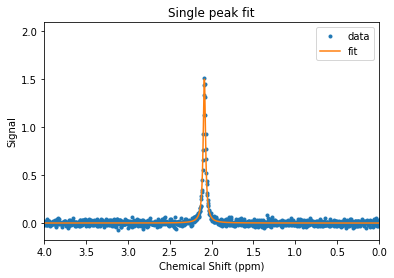

In [45]:
# Default initial parameter guess
outdat,parsFit,resids=pyFidA.op_peakFit(indat,ppmmin=1,ppmmax=3,peaktype='lorentz2')
f1,ax1=plt.subplots(1,1)
indat.plot_spec(xlims=[4,0],plotax=ax1,label='data',marker='.',linestyle='')
outdat.plot_spec(xlims=[4,0],plotax=ax1,label='fit')
ax1.set_title('Single peak fit')
ax1.legend()
print('Parameters: '+str(parsFit))

Note that parsFit return the FWHM value (the second parameter) in Hz, even though the lineshape function takes a value in ppm. This is because our FID object was has a transmit frequency of 300 MHz and op_peakFit uses this value to convert between the two. When making an initial guess for op_peakFit, the FWHM should also be entered in Hz. It is only when using the lineshape functions directly (eg. for simulating data) that FWHM values need to be in ppm, because there is no transmit frequency available to these functions.

You can also see that the baseline offset (second-last parameter) is complex and both this and the phase are close to zero (phase is in degrees).

## Optional parameters

Area under the fitted curve is: 0.0509227327906978
Parameters: [1.4963924650122458, 10.209099681001348, 2.0864530200371076]


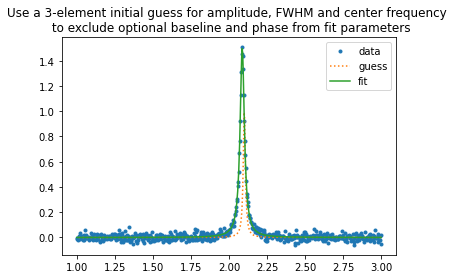

In [48]:
# Use an explicit initial guess as input for parsGuess in order to avoid fitting the baseline and phase
outdat,parsFit,resids=pyFidA.op_peakFit(indat,ppmmin=1,ppmmax=3,peaktype='lorentz2',parsGuess=[1,5,2.1],show_plot='partial')
plt.gca().set_title('Use a 3-element initial guess for amplitude, FWHM and center frequency \n to exclude optional baseline and phase from fit parameters')
print('Parameters: '+str(parsFit))

Here, I've used the input argument show_plot='partial' to plot both the fit and the initial guess in the region that we defined with ppmmin and ppmmax (show_plot=True would plot the entire spectrum, even though we have only fit a portion of it).


## Available lineshapes, parameter order and FWHM units

The peaktype='lorentz2' corresponds to the op_lorentz function and the help information on this function tells us the parameter order as well as the units, under the "Parameters" section for the input parameter "pars". However, the FWHM is a special case because op_peakFit converts this number from Hz to ppm before sending it to op_lorentz, then converts it from ppm back to Hz before returning it as the parsFit result. This conversion is only implemented for string values of peaktype (where the position of the FWHM parameter in the parameter list is known).

In [6]:
help(pyFidA.op_lorentz)

Help on function op_lorentz in module pyFidA.fidA_processing.op_peak_fitting:

op_lorentz(pars, ppm)
    yvals=op_lorentz(pars,ppm)
    Wrapper function for op_lorentz_linbas that fixes the baseline slope to 
    zero. This is useful if you want to fit a function with a flat baseline 
    that has an intercept but no slope. All other aspects of 
    op_lorentz_linbas apply: baseline intercept and phase shift are optional 
    parameters; peak amplitudes, fwhm and center frequencies may be supplied as 
    scalars for a single peak or as lists/numpy arrays for multiple peaks.
    
    Parameters
    ----------
    pars : list
        List of parameters to be fitted in the order 
        [amplitude, fwhm (in ppm), center frequency (in ppm), baseline offset, phase shift (in degrees)].
        The baseline offset and phase shift parameters are optional and are 
        scalars. The amplitude, fwhm and center frequency are required and can 
        be scalars (for a single peak) or lists/nu

The implemented peaktype values are available with help(pyFidA.op_peakFit) but it is also possible to enter a function name (a pyFid lineshape function or a user-defined function) directly. However, default initial parameter guess and parameter bounds (covered later) are not implemented in this case. They are only available for the string peaktype options, where they have been hard-coded based on the known function construction.

The code below is equivalent to the above, but uses a callable function instead of a pre-defined string reference for peaktype. Because there is no information about this function hard-coded into op_peakFit, it does not "know" which parameter is the FWHM and now the FWHM should be entered in ppm and will be returned in ppm. Using a value that appears to be in Hz (eg. the 5 Hz value that we used above), throws a warning, and the fit takes more time to converge, although it is eventually successful in this case. The dashed orange line showing the initial guess demonstrates how far off the initial FWHM was.

Area under the fitted curve is: 0.050922733405409114
Parameters: [1.4963924473243375, 0.03403033308305104, 2.086453019998731]


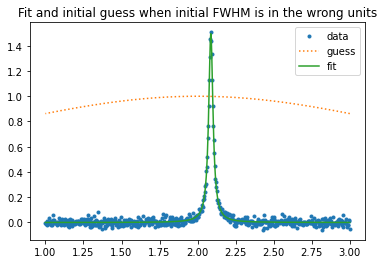

In [50]:
# Specifying peaktype as a callable function. The FWHM in parsGuess and the final fit will now be in ppm
outdat,parsFit,resids=pyFidA.op_peakFit(indat,ppmmin=1,ppmmax=3,peaktype=pyFidA.op_lorentz,parsGuess=[1,5,2],show_plot='partial')
plt.gca().set_title('Fit and initial guess when initial FWHM is in the wrong units')
print('Parameters: '+str(parsFit))

## Fitting multiple peaks
Multiple peaks can be fit with a similar method. The parameters for the function have the same order. But the amplitude, FWHM and center frequency parameters become lists or arrays (either is accepted and the output parameters will have the same type as the inputs). The baseline and phase parameters are scalars, with one value for the entire spectrum, and they remain optional.

One helpful tip, if you do not know the center frequencies exactly, is to use an initial guess with a fairly wide FWHM guess. This helps the function to find the peak and begin converging using the data in this region.

Area under the fitted curve is: [0.050966391117375894, 0.034191204506265636, 0.05084326658810113]
Parameters: [[1.4964921669510802, 1.9909904408993202, 1.0074786154627764], [10.217171645050508, 5.151888799248324, 15.139755566349184], [2.0846806130391595, 4.649822744406625, 6.188832693632077]]


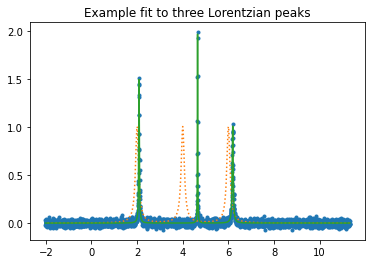

In [51]:
initGuess=[[1,1,1],[50,50,50],[2,4,6]]
outdat,parsFit,resids=pyFidA.op_peakFit(indat,ppmmin=0,ppmmax=8,peaktype='lorentz2',parsGuess=initGuess,show_plot=True)
plt.gca().set_title('Example fit to three Lorentzian peaks')
print('Parameters: '+str(parsFit))

## Fitting the baseline and complex parameters
A baseline offset and slope can also be fit for. In general, a DC offset can be complex. To fit a complex parameter value, the initial parsGuess value in this parameter position _must_ use a complex value\*. The default values when no initial parsGuess is entered in op_peakFit also assume complex values for baseline slope and offset, unless the input argument real_ydata=True is used, as described below.

\* The actual requirement used by nlinfit, the fitting function called in op_peakFit, to determine whether a parameter is expected to be complex is that np.iscomplexobj(parval)=True. This is noted because np.iscomplex(parval) will return False if parval=0+0j since the imaginary component is zero. Whereas np.iscomplexobj(parval) will return True. Additionally, np.iscomplexobj is applied to the entire list of (for example) amplitude values in the multipeak case, meaning that, if any of these values are complex, then the fit will assume that all amplitude values should be fit as complex numbers. Of course, the amplitudes ought to be real numbers in any normal spectroscopic fit. It is anticipated that complex values will only be needed for the baseline slope and offset, but the function is set up to handle other cases for users who write their own functions.

Parameters: [[1.4964917740341828, 1.990957226919707, 1.0074643766706486], [10.213007948204076, 5.149251916264094, 15.120446356232536], [2.08468060529695, 4.64982274736901, 6.18883287318939], (1.0004592056836359+1.0004860912279627j)]


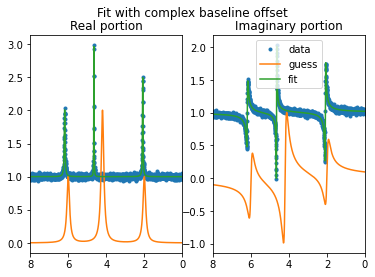

In [52]:
# Add a baseline to our simulated data
indat_baseline=indat+(1+1j)
# Now fit with a baseline parameter
initGuess=[[1,2,1],[50,50,50],[2,4.2,6],0+0j]
initGuess_ppm=[[1,2,1],[50/300,50/300,50/300],[2,4.2,6],0+0j]
outdat,parsFit,resids=pyFidA.op_peakFit(indat_baseline,ppmmin=0,ppmmax=8,peaktype='lorentz2',parsGuess=initGuess,show_plot=False)
f1,ax1=plt.subplots(1,2)
ax1[0].plot(indat_baseline.ppm,np.real(indat_baseline.specs),'.',label='data')
ax1[0].plot(outdat.ppm,np.real(pyFidA.op_lorentz(initGuess_ppm,outdat.ppm)),label='guess')
ax1[0].plot(outdat.ppm,np.real(outdat.specs),label='fit')
ax1[0].set_xlim([8,0])
ax1[0].set_title('Real portion')
ax1[1].plot(indat_baseline.ppm,np.imag(indat_baseline.specs),'.',label='data')
ax1[1].plot(outdat.ppm,np.imag(pyFidA.op_lorentz(initGuess_ppm,outdat.ppm)),label='guess')
ax1[1].plot(outdat.ppm,np.imag(outdat.specs),label='fit')
ax1[1].set_xlim([8,0])
ax1[1].legend()
ax1[1].set_title('Imaginary portion')
f1.suptitle('Fit with complex baseline offset')
print('Parameters: '+str(parsFit))

## Fitting just the real part of the spectrum

If a real value is entered for the baseline offset, then the fit will only use a real value for this parameter. In cases with complex data (which all FID objects input into op_peakFit are expected to have for their spectra), this may result in poor fit metrics and parameter errors or even failed fits because the imaginary part of the offset can never be corrected:

Paramters: [[-1.1369870927203756, 0.1738560393696999, 0.11219421762135287], [13130.590653538005, -2788.926121111463, -144.06189872364627], [-33.799610337084545, 8.717079503703548, 8.396342709196093], 1.653471323586596]


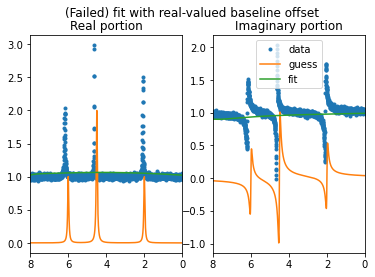

In [55]:
# Fitting with complex ydata but only a real value for the baseline offset
# In this case, the fit fails, even when the initial parameters are adjusted
# to get close to the actual values. This is because the imaginary half of 
# the data are not fit well, particularly the offset
initGuess=[[5,5,5],[20,20,20],[2,4.5,6],0]
initGuess_ppm=[[1,2,1],[20/300,20/300,20/300],[2,4.5,6],0]
outdat,parsFit,resids=pyFidA.op_peakFit(indat_baseline,ppmmin=0,ppmmax=8,peaktype='lorentz2',parsGuess=initGuess,show_plot=False)
f1,ax1=plt.subplots(1,2)
ax1[0].plot(indat_baseline.ppm,np.real(indat_baseline.specs),'.',label='data')
ax1[0].plot(outdat.ppm,np.real(pyFidA.op_lorentz(initGuess_ppm,outdat.ppm)),label='guess')
ax1[0].plot(outdat.ppm,np.real(outdat.specs),label='fit')
ax1[0].set_xlim([8,0])
ax1[0].set_title('Real portion')
ax1[1].plot(indat_baseline.ppm,np.imag(indat_baseline.specs),'.',label='data')
ax1[1].plot(outdat.ppm,np.imag(pyFidA.op_lorentz(initGuess_ppm,outdat.ppm)),label='guess')
ax1[1].plot(outdat.ppm,np.imag(outdat.specs),label='fit')
ax1[1].set_xlim([8,0])
ax1[1].legend()
ax1[1].set_title('Imaginary portion')
f1.suptitle('(Failed) fit with real-valued baseline offset')
print('Paramters: '+str(parsFit))

In general, it makes sense to fit both the real and imaginary parts of the data when both are available, to avoid throwing data away. However, this behaviour differs from Matlab's op_peakFit function, which uses only the real portion of the input spectrum and fits the real portion of the output from a voigt lineshape function to that.

Because of this, and because there may be cases where users have their own functions that produce real-valued data, there is an option to fit only the real portion of the spectrum by setting real_ydata=True in the input arguments to op_peakFit. In cases where the lineshape functions yields a complex result, a warning will be thrown to note that only the real portion of this output is being used in the fit.

In the case where the fit is restricted to the real portion of the spectrum, the default initial parameter guess for the string options of the peaktype parameters also uses entirely real parameters.

/Users/nearlabmacbook1/Documents/PythonScripts/pyFidA/docs/tutorials/../../pyFidA/fidA_processing/curvefit_tools.py:177: FidAWarning: WARNING: Function produces complex output but data to compare with appear to be real. Taking real part of function output
  warnings.warn('WARNING: Function produces complex output but data to compare with appear to be real. Taking real part of function output',FidAWarning)


Parameters: [[0.03329195792019924, -1.9832734513545365, -0.019659433458597206], [-10.112982534828417, -4.9390537305032725, 2.4913080291388616], [1.7383525383405756, 4.649889672520666, 5.924069387410459], 1.020884155634879]


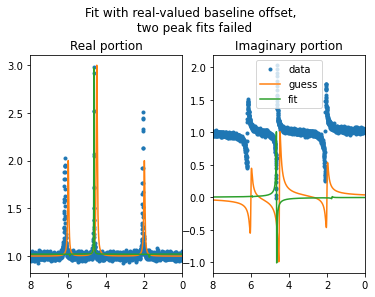

In [64]:
# We can restrict construct a temporary FID that only has the real portion of the data
# pyFidA will then use only the real portion of the output of op_lorentz for fitting
# although the outdat FID object that is output will include the imaginary portion
initGuess=[[1,2,1],[20,20,20],[2,4.6,6],1]
outdat,parsFit,resids=pyFidA.op_peakFit(indat_baseline,ppmmin=0,ppmmax=8,peaktype='lorentz2',real_ydata=True,parsGuess=initGuess,show_plot=False)
f1,ax1=plt.subplots(1,2)
ax1[0].plot(indat_baseline.ppm,np.real(indat_baseline.specs),'.',label='data')
initGuess_ppm=[[1,2,1],[20/300,20/300,20/300],[2,4.5,6],1]
ax1[0].plot(outdat.ppm,np.real(pyFidA.op_lorentz(initGuess_ppm,outdat.ppm)),label='guess')
ax1[0].plot(outdat.ppm,np.real(outdat.specs),label='fit')
ax1[0].set_xlim([8,0])
ax1[0].set_title('Real portion')
ax1[1].plot(indat_baseline.ppm,np.imag(indat_baseline.specs),'.',label='data')
ax1[1].plot(outdat.ppm,np.imag(pyFidA.op_lorentz(initGuess_ppm,outdat.ppm)),label='guess')
ax1[1].plot(outdat.ppm,np.imag(outdat.specs),label='fit')
ax1[1].set_xlim([8,0])
ax1[1].legend()
ax1[1].set_title('Imaginary portion')
f1.suptitle('Fit with real-valued baseline offset, \n two peak fits failed',y=1.05)
print('Parameters: '+str(parsFit))

In this case, the fit still fails for two of the peaks, even though it appears to converge, and it produces inaccurate parameter values in this case. This is true even when the initial parameter guess is set very close to the true values. This is partly because of the smaller amount of data available for fitting, particularly in the peak regions, when the imaginary data are not used. In general, it makes sense to make use of the complex data when fitting, but the ability to just fit the real portion of the spectrum is available for users who only have access to real-valued data and/or who are fitting user-defined functions that return real-valued data.

Note that the final output spectrum still has an imaginary component since the fitting function produces complex data, but you can see that the imaginary component of the baseline offset cannot be determined since these data are not used for fitting.

Looking at the parameter values themselves, some are not just inaccurate but unphysical! For example, there are negative linewidths. You can use the parameter_bounds input argument to restrict parameters to an expected range.

## Parameter bounds
There are two ways to do to add bounds to the fit parameters.

Users can enter lower and upper bounds as a two-element list/tuple for the input argument parameter_bounds. Each element should have the same format as the initial guess.

Alternatively, for the pre-defined lineshape functions that have string values for peaktype, default parameter bounds have been defined based on the known information about the parameter order and reasonable physical assumptions for each of them (eg. amplitudes between 0 and 2x the maximum amplitude of the spectrum). These can be used by setting parameter_bounds=True.

/Users/nearlabmacbook1/Documents/PythonScripts/pyFidA/docs/tutorials/../../pyFidA/fidA_processing/curvefit_tools.py:177: FidAWarning: WARNING: Function produces complex output but data to compare with appear to be real. Taking real part of function output
  warnings.warn('WARNING: Function produces complex output but data to compare with appear to be real. Taking real part of function output',FidAWarning)


Area under the fitted curve is: [0.05077119872285673, 0.033985465382856725, 0.050689348704826644]
Parameters: [[1.5014651835923776, 1.9867836326341657, 1.0025106141045679], [10.144330873137365, 5.131731230007762, 15.168721804537256], [2.0847094376454467, 4.649887325506546, 6.18879801518257], 1.0005521601297394]


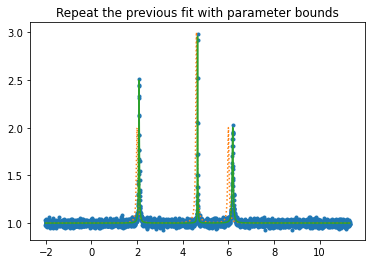

In [65]:
initGuess=[[1,2,1],[20,20,20],[2,4.6,6],1]
lbs=[[0,0,0],[1,1,1],[1,3,5],-5]
maxy=np.amax(np.real(indat_baseline.specs))
ubs=[[2*maxy,2*maxy,2*maxy],[30,30,30],[3,5,7],5]
outdat,parsFit,resids=pyFidA.op_peakFit(indat_baseline,ppmmin=0,ppmmax=8,peaktype='lorentz2',parsGuess=initGuess,real_ydata=True,show_plot=True,parameter_bounds=[lbs,ubs])
plt.gca().set_title('Repeat the previous fit with parameter bounds')
print('Parameters: '+str(parsFit))

/Users/nearlabmacbook1/Documents/PythonScripts/pyFidA/docs/tutorials/../../pyFidA/fidA_processing/curvefit_tools.py:177: FidAWarning: WARNING: Function produces complex output but data to compare with appear to be real. Taking real part of function output
  warnings.warn('WARNING: Function produces complex output but data to compare with appear to be real. Taking real part of function output',FidAWarning)


Area under the fitted curve is: [0.0717722916204254, 0.03970720891171372, 0.012976654275540069]
Parameters: [[0.5677695425033938, 0.8397492772869367, 0.3086563947611034], [37.92328730983119, 14.185380083922132, 12.612718701892298], [2.084734544610137, 4.6498371314679625, 6.000592789075667], 1.0028815772691688]


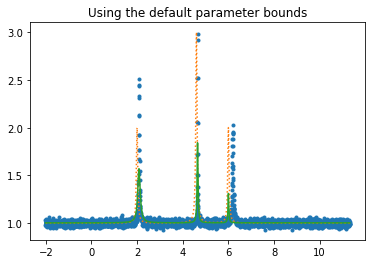

In [66]:
initGuess=[[1,2,1],[20,20,20],[2,4.6,6],1]
outdat,parsFit,resids=pyFidA.op_peakFit(indat_baseline,ppmmin=0,ppmmax=8,peaktype='lorentz2',parsGuess=initGuess,real_ydata=True,show_plot=True,parameter_bounds=True)
plt.gca().set_title('Using the default parameter bounds')
print('Parameters: '+str(parsFit))

In the above case, the default parameter bounds are still not enough of a constraint to produce a good fit without the complex portion of the data and the user-defined bounds are a better option.

## Other lineshapes
Although the initial lineshape function was constructed with Lorentzians, it is possible to fit other lineshapes. For example, you can fit with a Gaussian. Because the data are not Gaussian, the fit quality will be poorer and the fit parameter values will change. However, the fit will likely converge because the differences in many lineshapes cover only a small number of data points, near the tails, for example.

Area under the fitted curve is: 0.0509227327906978
Area under the fitted curve is: 0.05785253858799341
Lorentzian parameters: [1.4963924650122458, 10.209099681001348, 2.0864530200371076]
Gaussian parameters: [1.33905531693515, 12.96119835894618, 2.0864462006619755]


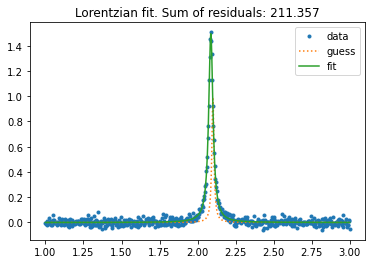

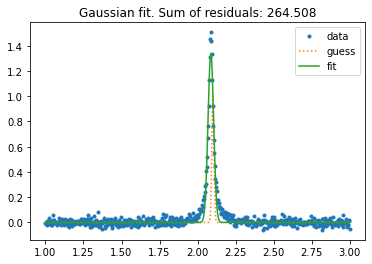

In [67]:
outdat_lorentz,parsFit_lorentz,resids_lorentz=pyFidA.op_peakFit(indat,ppmmin=1,ppmmax=3,peaktype='lorentz',parsGuess=[1,5,2.1],show_plot='partial')
plt.gca().set_title('Lorentzian fit. Sum of residuals: {:3.3f}'.format(np.sum(np.abs(resids_lorentz.specs))))
outdat_gauss,parsFit_gauss,resids_gauss=pyFidA.op_peakFit(indat,ppmmin=1,ppmmax=3,peaktype='gauss',parsGuess=[1,5,2.1],show_plot='partial')
plt.gca().set_title('Gaussian fit. Sum of residuals: {:3.3f}'.format(np.sum(np.abs(resids_gauss.specs))))
print('Lorentzian parameters: '+str(parsFit_lorentz))
print('Gaussian parameters: '+str(parsFit_gauss))

## Advanced topics: More on optional parameters and user-defined functions
As mentioned, some fit parameters are optional and can be excluded from the fit. However, the excluded parameters must start from the end of the parameter list. Thus, for op_lorentz_linbas, you can exclude the phase by entering only the first five parameters. Or you can exclude the phase and the baseline offset, but include the baseline slope, by entering the first four parameters. It is not possible to remove the baseline slope and just fit for the baseline offset with op_lorentz_linbas because of the way that the parameters are ordered.

A new function is required for this, op_lorentz. In this case, the op_lorentz function is already written. However, it is possible to write your own functions that include only the parameters that you want. In fact, the code for op_lorentz shows how this is possible, fixing a parameter value and then calling op_lorentz_linbas. In this section, you'll see something similar, this time writing a function that fits a lorentzian with amplitude, fwhm and center frequency parameters, as well as a phase, but no baseline offset.

First, let's add phase onto our simulated spectrum and do a fit with the full parameter list for op_lorentz_linbas on one of the peaks.

Area under the fitted curve is: 0.05090487740755332
All 6 parameters fit, but baseline parameters near 0: [1.4959940646379977, 10.208237842147724, 2.0861828669380658, -0.0018235113255753355, 0.004139586545827215, 10.915628143478985]


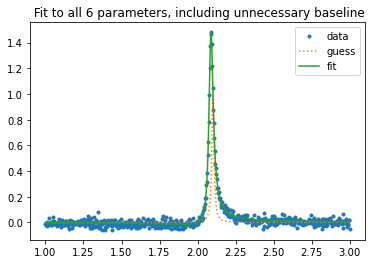

In [69]:
# Add some phase to our simulated data
indat_wphase=pyFidA.op_addphase(indat,10)
# Do a fit with the phase included. Even though the baseline slope and offset are 0, 
# these values must be included in the fit because optional parameters are excluded
# starting from the end of the list.
initPars=[1,5,2.1,0,0,0]
outdat,parsFit,resids=pyFidA.op_peakFit(indat_wphase,ppmmin=1,ppmmax=3,peaktype='lorentz',parsGuess=initPars,show_plot='partial')
plt.gca().set_title(' Fit to all 6 parameters, including unnecessary baseline')
print('All 6 parameters fit, but baseline parameters near 0: '+str(parsFit))

The fitted parameter values are near the ground truth. However, the baseline offset and slope parameters are near 0. This is as expected, but also indicates that they are not needed for the fit. But there is no way to fit just for the phase *without* including these other baseline parameters using the existing op_lorentz_linbas function (or even the op_lorentz function).

If you want to fit with phase and no baseline parameters, you need to construct a new function. The new function will have to have input arguments in the order (pars,ppm) and then split pars up into the phase parameter, which can be used with pyFidA.add_phase, and the remaining parameters to send to op_lorentz (or op_lorentz_linbas; it doesn't matter in this case since only the amplitude, FWHM and center frequency parameters will be passed through).

This new function should then be passed as the argument to peaktype in op_peakFit. Because the new function is not "known" to op_peakFit, it is no longer possible to have a "smart" default parsGuess or parameter_bounds, and the linewidth parameter will now be in ppm.

In [70]:
def newfunc(pars, ppm):
    """
    Example fitting function where pars is [amplitude, FWHM, center frequency, zeroth-order phase].
    """
    yvals=pyFidA.op_lorentz(pars[:3],ppm)
    phased_y=pyFidA.add_phase(yvals,pars[3])
    return phased_y

Area under the fitted curve is: 0.05092837752660955
Fit to new function, with just 4 parameters where the last is the phase: [1.4960619062739768, 0.0340416244227817, 2.0862103679604975, 10.820066051795703]


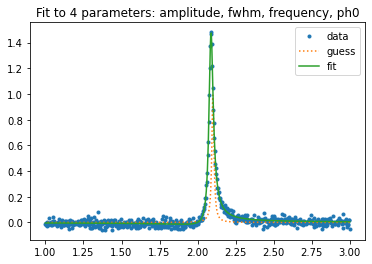

In [71]:
initPars=[1,5/300,2.1,0]
outdat,parsFit,resids=pyFidA.op_peakFit(indat_wphase,ppmmin=1,ppmmax=3,peaktype=newfunc,parsGuess=initPars,show_plot='partial')
plt.gca().set_title('Fit to 4 parameters: amplitude, fwhm, frequency, ph0')
print('Fit to new function, with just 4 parameters where the last is the phase: '+str(parsFit))